In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [14]:
df = pd.read_csv("../csvfiles/main_dataset.csv")
df.head()

,السنة الدراسية,المرحلة الدراسية,المستوى الدراسي,نوع المؤسسة التعليمية,المنطقة الإدارية,نوع الجهة,الجهة التعليمية,المجال الواسع,المجال الضيق,المجال التفصيلي,نظام الدراسة,الجنس,الجنسية,العدد,حالة_الطالب
0,2021,بكالوريوس,بكالوريوس,الجامعات الحكومية,المنطقة الشرقية,جامعة,الجامعة السعودية الإلكترونية,الأعمال والإدارة والقانون,الأعمال والإدارة,التسويق والإعلان,انتظام,أنثى,سعودي,181,مستجد
1,2021,بكالوريوس,بكالوريوس,الجامعات الحكومية,المنطقة الشرقية,جامعة,الجامعة السعودية الإلكترونية,الأعمال والإدارة والقانون,الأعمال والإدارة,التسويق والإعلان,انتظام,أنثى,غير سعودي,8,مستجد
2,2021,بكالوريوس,بكالوريوس,الجامعات الحكومية,المنطقة الشرقية,جامعة,الجامعة السعودية الإلكترونية,الأعمال والإدارة والقانون,الأعمال والإدارة,التسويق والإعلان,انتظام,ذكر,سعودي,131,مستجد
3,2021,بكالوريوس,بكالوريوس,الجامعات الحكومية,المنطقة الشرقية,جامعة,الجامعة السعودية الإلكترونية,الأعمال والإدارة والقانون,الأعمال والإدارة,التسويق والإعلان,انتظام,ذكر,غير سعودي,5,مستجد
4,2021,بكالوريوس,بكالوريوس,الجامعات الحكومية,المنطقة الشرقية,جامعة,الجامعة السعودية الإلكترونية,الأعمال والإدارة والقانون,الأعمال والإدارة,التسيير والإدارة,انتظام,أنثى,سعودي,505,مستجد


Check the shape of the data

In [15]:
df.shape

(18907, 15)

In [16]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18907 entries, 0 to 18906
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   السنة الدراسية         18907 non-null  int64 
 1   المرحلة الدراسية       18907 non-null  object
 2   المستوى الدراسي        18907 non-null  object
 3   نوع المؤسسة التعليمية  18907 non-null  object
 4   المنطقة الإدارية       18907 non-null  object
 5   نوع الجهة              18907 non-null  object
 6   الجهة التعليمية        18907 non-null  object
 7   المجال الواسع          18907 non-null  object
 8   المجال الضيق           18907 non-null  object
 9   المجال التفصيلي        18907 non-null  object
 10  نظام الدراسة           18907 non-null  object
 11  الجنس                  18907 non-null  object
 12  الجنسية                18907 non-null  object
 13  العدد                  18907 non-null  int64 
 14  حالة_الطالب            18907 non-null  object
dtypes: int64(2), object

,السنة الدراسية,العدد
count,18907.000000,18907.000000
mean,2022.022954,74.757550
std,0.811429,293.539873
min,2021.000000,1.000000
25%,2021.000000,3.000000
50%,2022.000000,14.000000
75%,2023.000000,63.000000
max,2023.000000,22300.000000


In [17]:
df["حالة_الطالب"].unique()

array(['مستجد', 'خريج'], dtype=object)

In [18]:

df["الجنس"].value_counts()

الجنس
ذكر     9518
أنثى    9389
Name: count, dtype: int64

In [19]:
df["الجنسية"].value_counts()

الجنسية
سعودي        13253
غير سعودي     5654
Name: count, dtype: int64

In [20]:
#get the increases in the number of participants over the years
new_students = df[(df["المرحلة الدراسية"] == "بكالوريوس") & 
                  (df["حالة_الطالب"] == "مستجد")]

In [21]:
new_students.describe()

,السنة الدراسية,العدد
count,4699.000000,4699.000000
mean,2022.038944,117.614599
std,0.799089,325.145719
min,2021.000000,1.000000
25%,2021.000000,3.000000
50%,2022.000000,33.000000
75%,2023.000000,120.000000
max,2023.000000,7371.000000


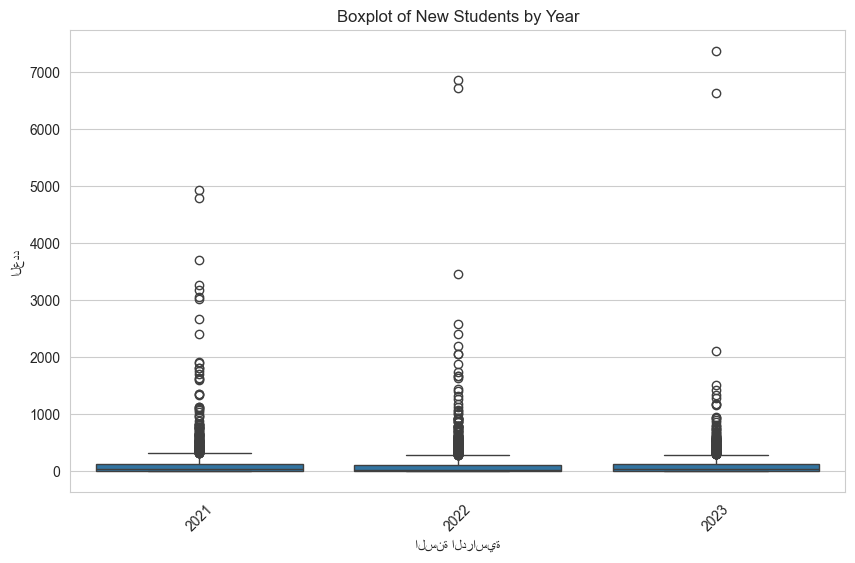

In [22]:
#plot boxplot of new_students
plt.figure(figsize=(10, 6))
sns.boxplot(x="السنة الدراسية",y="العدد", data=new_students)
plt.xticks(rotation=45)
plt.title("Boxplot of New Students by Year")
plt.show()

In [23]:


Q1 = new_students['العدد'].quantile(0.25)
Q3 = new_students['العدد'].quantile(0.75)

IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
# new_students = new_students[(new_students['العدد'] >= lower_bound) & (new_students['العدد'] <= upper_bound)]

Lower Bound: -172.5, Upper Bound: 295.5


In [24]:
# sum students per year
yearly_new = new_students.groupby("السنة الدراسية")["العدد"].sum()
yearly_new

السنة الدراسية
2021    185727
2022    198574
2023    168370
Name: العدد, dtype: int64

In [25]:
df["المرحلة الدراسية"].unique()

array(['بكالوريوس', 'دبلوم متوسط', 'دبلوم مشارك', 'دراسات عليا',
       'دكتوراه'], dtype=object)

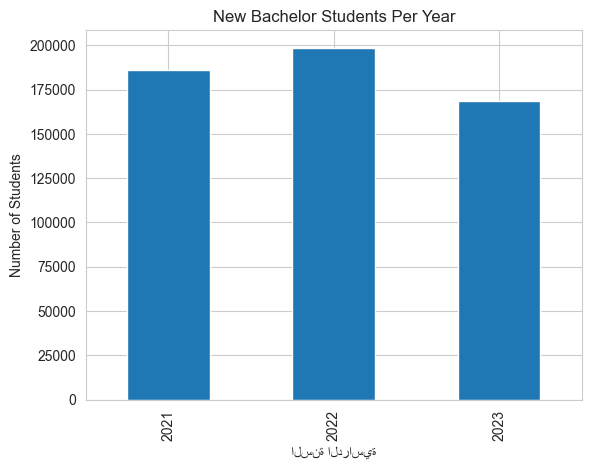

In [26]:
#plot the number of new bachelor students per year
yearly_new.plot(kind="bar")
plt.title("New Bachelor Students Per Year")
plt.ylabel("Number of Students")
plt.show()

<Axes: xlabel='الجنسية'>

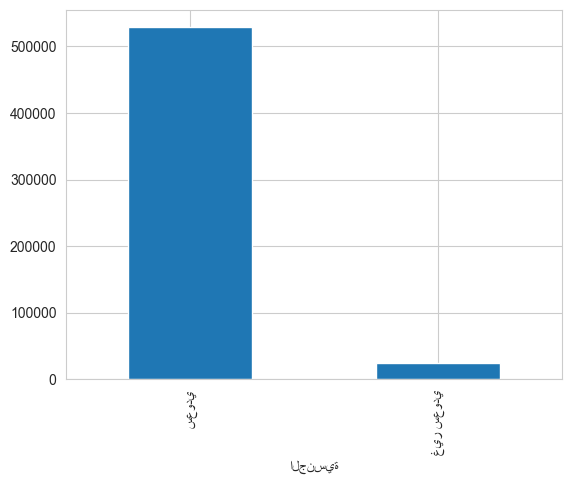

In [27]:
year_nat = new_students.groupby(["الجنسية"])["العدد"].sum()
year_nat.plot(kind="bar")

In [28]:
year_gender = new_students.groupby(["السنة الدراسية", "الجنس"])["العدد"].sum()
year_gender

السنة الدراسية  الجنس
2021            أنثى     106730
                ذكر       78997
2022            أنثى     114524
                ذكر       84050
2023            أنثى      91933
                ذكر       76437
Name: العدد, dtype: int64

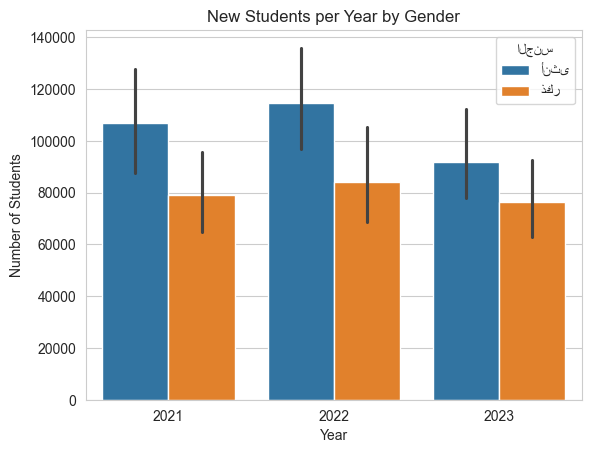

In [29]:
sns.barplot(
    data=new_students,
    x="السنة الدراسية",
    y="العدد",
    hue="الجنس",
    estimator=sum  # sums the values per group
)

plt.title("New Students per Year by Gender")
plt.ylabel("Number of Students")
plt.xlabel("Year")
plt.show()

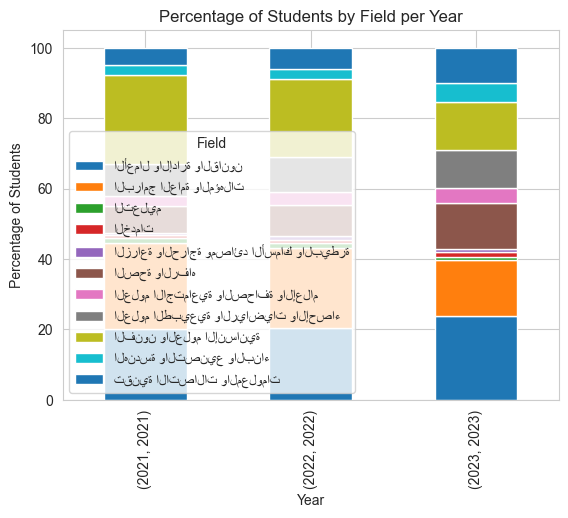

In [43]:
#نسبة الطلاب (٪ من إجمالي العام) حسب المجال"
field_percent = new_students.groupby(["السنة الدراسية", "المجال الواسع"])["العدد"].sum().groupby(level=0).apply(lambda x: 100 * x / float(x.sum()))
field_percent.unstack().plot(kind="bar", stacked=True)
plt.title("Percentage of Students by Field per Year")
plt.ylabel("Percentage of Students")
plt.xlabel("Year")
plt.legend(title="Field")
plt.show()

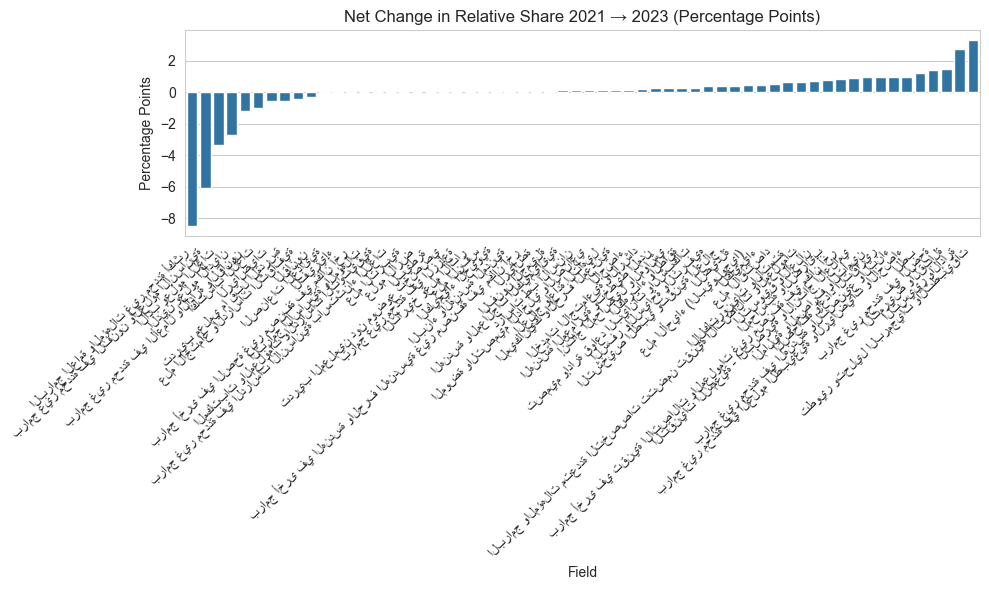

In [ ]:
# حساب الحصة النسبية لكل مجال في كل سنة
field_year = (
    new_students.groupby(["السنة الدراسية", "المجال التفصيلي"])["العدد"]
    .sum()
)

# تحويل إلى نسبة مئوية داخل كل سنة
field_year_pct = (
    field_year
    .groupby(level="السنة الدراسية")
    .transform(lambda x: x / x.sum() * 100)
)

# استخراج ٢٠٢١ و ٢٠٢٣
pct_2021 = field_year_pct.xs(2021, level="السنة الدراسية")
pct_2023 = field_year_pct.xs(2023, level="السنة الدراسية")
net_change = (pct_2023 - pct_2021).dropna().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=net_change.index, y=net_change.values)
plt.title("Net Change in Relative Share 2021 → 2023 (Percentage Points)")
plt.ylabel("Percentage Points")
plt.xlabel("Field")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

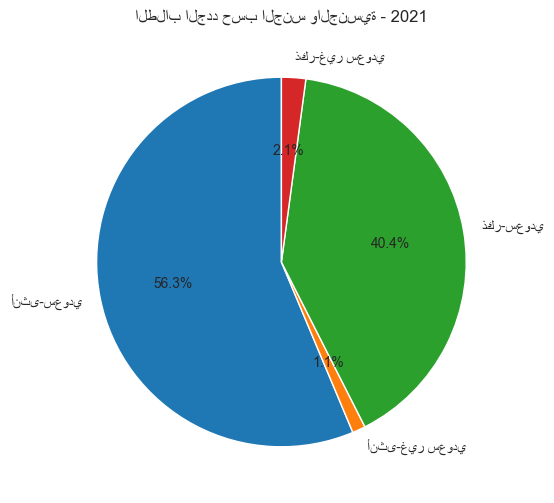

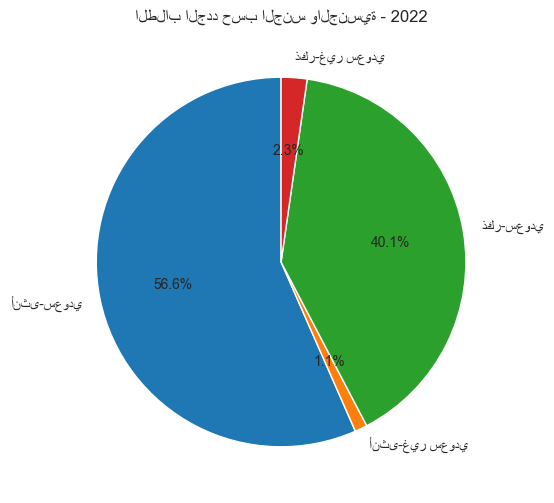

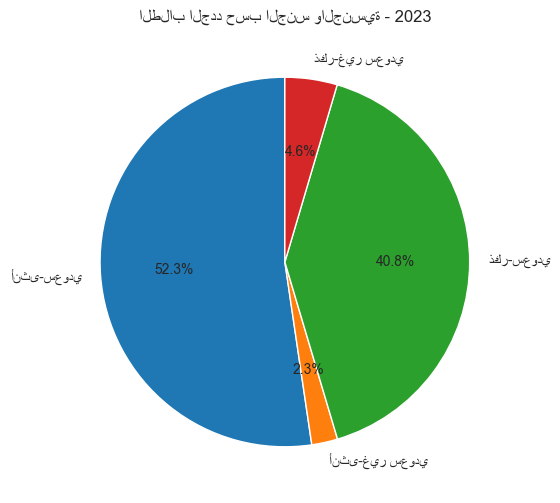

In [33]:

# pivot as you already did
pivot = new_students.pivot_table(
    index="السنة الدراسية",
    columns=["الجنس", "الجنسية"],
    values="العدد",
    aggfunc="sum",
    fill_value=0
)
pivot.columns = [f"{g}-{n}" for g, n in pivot.columns]

# plot a pie chart for each year
for year in pivot.index:
    plt.figure(figsize=(6,6))
    plt.pie(
        pivot.loc[year],
        labels=pivot.columns,
        autopct='%1.1f%%',
        startangle=90
    )
    plt.title(f"الطلاب الجدد حسب الجنس والجنسية - {year}")
    plt.show()

In [34]:
pivot.head()

,أنثى-سعودي,أنثى-غير سعودي,ذكر-سعودي,ذكر-غير سعودي
السنة الدراسية,,,,
2021,104599,2131,75065,3932
2022,112363,2161,79565,4485
2023,88109,3824,68744,7693


In [35]:
year2023 = new_students[new_students["السنة الدراسية"]==2023]
year2023.head(2)


,السنة الدراسية,المرحلة الدراسية,المستوى الدراسي,نوع المؤسسة التعليمية,المنطقة الإدارية,نوع الجهة,الجهة التعليمية,المجال الواسع,المجال الضيق,المجال التفصيلي,نظام الدراسة,الجنس,الجنسية,العدد,حالة_الطالب
5716,2023,بكالوريوس,بكالوريوس,الجامعات الحكومية,المنطقة الشرقية,جامعة,الجامعة السعودية الإلكترونية,الأعمال والإدارة والقانون,الأعمال والإدارة,التسويق والإعلان,انتظام,أنثى,سعودي,189,مستجد
5717,2023,بكالوريوس,بكالوريوس,الجامعات الحكومية,المنطقة الشرقية,جامعة,الجامعة السعودية الإلكترونية,الأعمال والإدارة والقانون,الأعمال والإدارة,التسويق والإعلان,انتظام,أنثى,غير سعودي,8,مستجد


In [36]:
major_year = (
    new_students
    .groupby(["المجال التفصيلي", "السنة الدراسية"])["العدد"]
    .sum()
    .reset_index()
)

major_year = major_year.sort_values(["المجال التفصيلي", "السنة الدراسية"])

major_year["change"] = major_year.groupby("المجال التفصيلي")["العدد"].diff()

In [37]:
big_change = (
    major_year.groupby("المجال التفصيلي")["change"]
    .max()
    .abs()
    .nlargest(15)
    .index
)

In [38]:
major_year.head()

,المجال التفصيلي,السنة الدراسية,العدد,change
0,إنتاج المحاصيل والمواشي,2021,62,NaN
1,إنتاج المحاصيل والمواشي,2022,620,558.0
2,إنتاج المحاصيل والمواشي,2023,487,-133.0
3,اكتساب اللغات,2021,8848,NaN
4,اكتساب اللغات,2022,9826,978.0


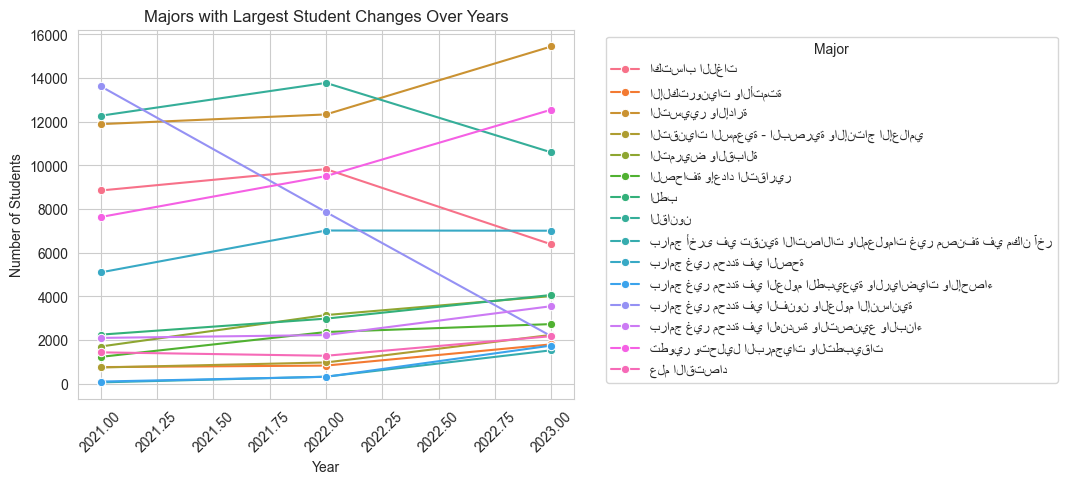

In [39]:

sns.lineplot(
    data=major_year[major_year["المجال التفصيلي"].isin(big_change)],
    x="السنة الدراسية",
    y="العدد",
    hue="المجال التفصيلي",
    marker="o"
)

plt.title("Majors with Largest Student Changes Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.legend(title="Major", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


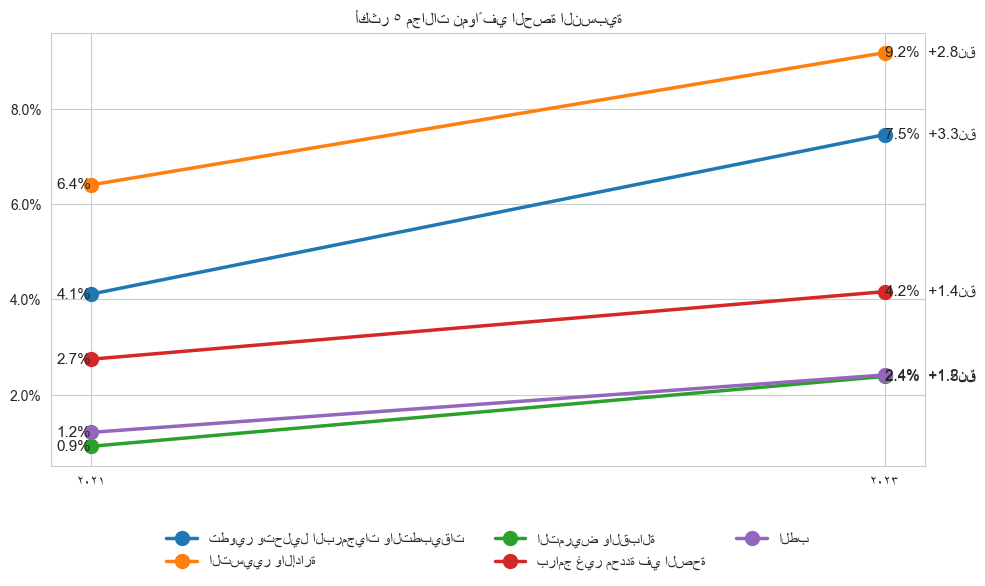

In [51]:
# حساب الحصة النسبية لكل مجال في كل سنة
field_year = (
    new_students.groupby(["السنة الدراسية", "المجال التفصيلي"])["العدد"]
    .sum()
)

field_year_pct = (
    field_year
    .groupby(level="السنة الدراسية")
    .transform(lambda x: x / x.sum() * 100)
    .reset_index()
)
field_year_pct.columns = ["السنة الدراسية", "المجال التفصيلي", "النسبة٪"]

# استخراج ٢٠٢١ و ٢٠٢٣
pct_2021 = field_year_pct[field_year_pct["السنة الدراسية"] == 2021].set_index("المجال التفصيلي")["النسبة٪"]
pct_2023 = field_year_pct[field_year_pct["السنة الدراسية"] == 2023].set_index("المجال التفصيلي")["النسبة٪"]

# بناء جدول التغيرات
change_df = pd.DataFrame({
    "المجال":   pct_2021.index,
    "٢٠٢١٪":   pct_2021.values,
    "٢٠٢٣٪":   pct_2023.reindex(pct_2021.index).values,
})
change_df["Δ٪"] = change_df["٢٠٢٣٪"] - change_df["٢٠٢١٪"]
gainers = change_df.nlargest(5, "Δ٪").reset_index(drop=True)

# الرسم
palette = sns.color_palette("tab10", len(gainers))

plt.figure(figsize=(10, 6))

for i, (_, row) in enumerate(gainers.iterrows()):
    plt.plot(
        [2021, 2023], [row["٢٠٢١٪"], row["٢٠٢٣٪"]],
        marker="o", linewidth=2.5, markersize=10,
        label=row["المجال"], color=palette[i]
    )
    plt.text(
        2021, row["٢٠٢١٪"],
        f"{row['٢٠٢١٪']:.1f}%",
        ha="right", va="center", fontsize=11
    )
    delta_str = f"+{row['Δ٪']:.1f}" if row["Δ٪"] > 0 else f"{row['Δ٪']:.1f}"
    plt.text(
        2023, row["٢٠٢٣٪"],
        f"{row['٢٠٢٣٪']:.1f}%  {delta_str}نق",
        ha="left", va="center", fontsize=11
    )

plt.xticks([2021, 2023], ["٢٠٢١", "٢٠٢٣"])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))
plt.title("أكثر ٥ مجالات نمواً في الحصة النسبية")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
           ncol=3, fontsize=11, frameon=False)
plt.tight_layout()
plt.show()

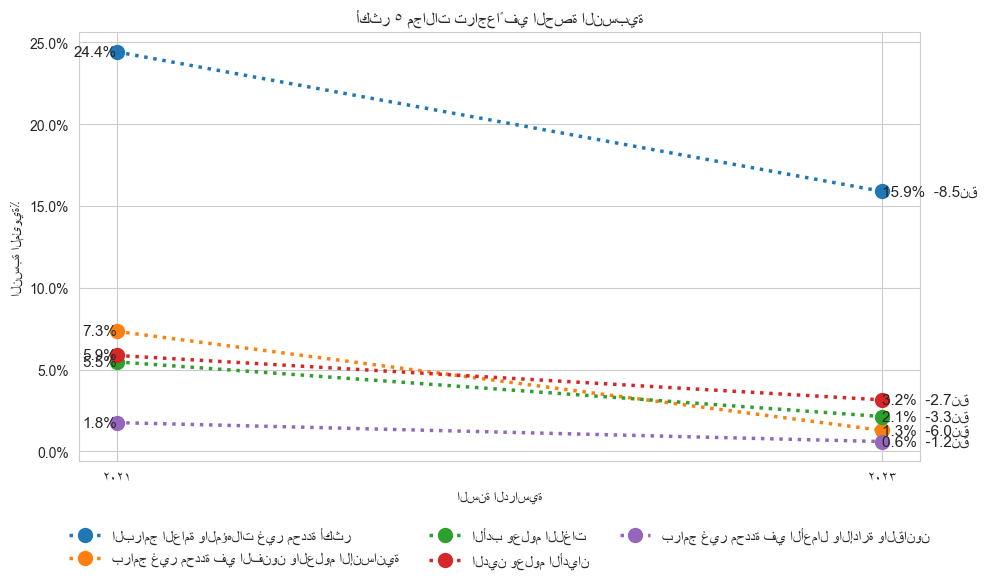

In [52]:
# أكثر ٥ مجالات تراجعاً في الحصة النسبية
losers = change_df.nsmallest(5, "Δ٪").reset_index(drop=True)
palette = sns.color_palette("tab10", len(losers))

plt.figure(figsize=(10, 6))

for i, (_, row) in enumerate(losers.iterrows()):
    plt.plot(
        [2021, 2023], [row["٢٠٢١٪"], row["٢٠٢٣٪"]],
        marker="o", linewidth=2.5, markersize=10,
        linestyle="dotted",
        label=row["المجال"], color=palette[i]
    )
    plt.text(
        2021, row["٢٠٢١٪"],
        f"{row['٢٠٢١٪']:.1f}%",
        ha="right", va="center", fontsize=11
    )
    plt.text(
        2023, row["٢٠٢٣٪"],
        f"{row['٢٠٢٣٪']:.1f}%  {row['Δ٪']:.1f}نق",
        ha="left", va="center", fontsize=11
    )

plt.xticks([2021, 2023], ["٢٠٢١", "٢٠٢٣"])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))
plt.title("أكثر ٥ مجالات تراجعاً في الحصة النسبية")
plt.ylabel("النسبة المئوية٪")
plt.xlabel("السنة الدراسية")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12),
           ncol=3, fontsize=11, frameon=False)
plt.tight_layout()
plt.show()

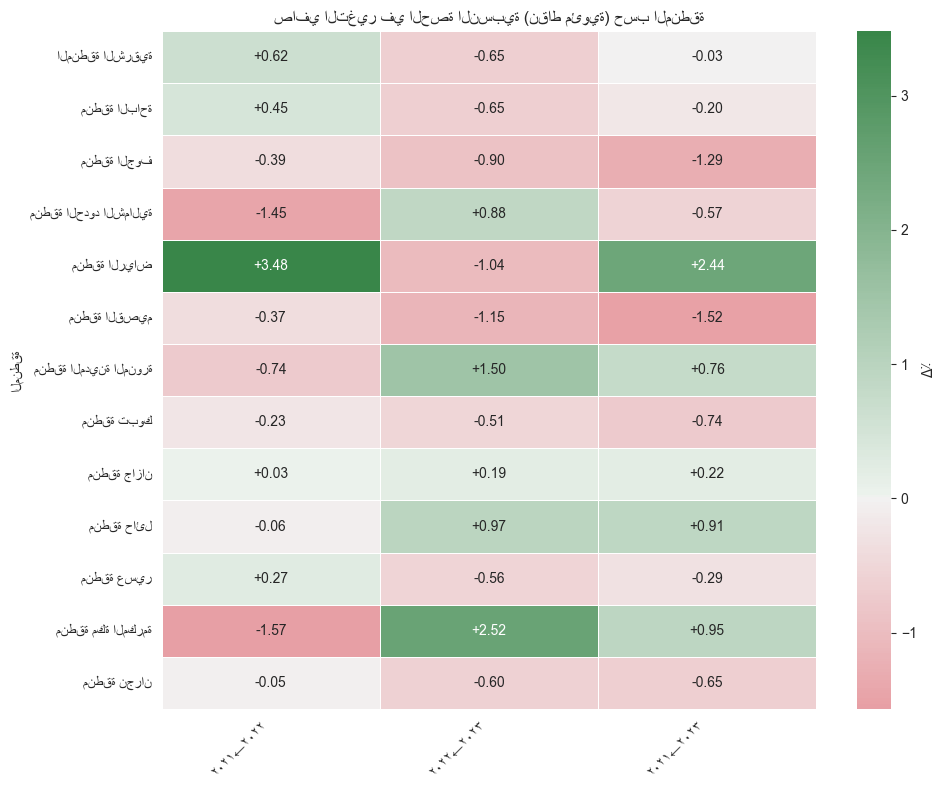

In [54]:
# Heatmap - صافي التغير في الحصة النسبية حسب المنطقة
rp = new_students.groupby(["السنة الدراسية", "المنطقة الإدارية"])["العدد"].sum().unstack(fill_value=0)

annual_total = new_students.groupby("السنة الدراسية")["العدد"].sum().to_dict()
YEARS = sorted(new_students["السنة الدراسية"].unique())

pct_reg = pd.DataFrame(index=rp.columns)
for yr_ in YEARS:
    tot = annual_total.get(yr_, 1)
    pct_reg[yr_] = (rp.loc[yr_] / tot * 100).round(2) if yr_ in rp.index else 0

delta_reg = pd.DataFrame(index=rp.columns)
if 2021 in rp.index and 2022 in rp.index:
    delta_reg["٢٠٢١←٢٠٢٢"] = (pct_reg[2022] - pct_reg[2021]).round(2)
if 2022 in rp.index and 2023 in rp.index:
    delta_reg["٢٠٢٢←٢٠٢٣"] = (pct_reg[2023] - pct_reg[2022]).round(2)
if 2021 in rp.index and 2023 in rp.index:
    delta_reg["٢٠٢١←٢٠٢٣"] = (pct_reg[2023] - pct_reg[2021]).round(2)

# الرسم
plt.figure(figsize=(10, 8))
sns.heatmap(
    delta_reg,
    annot=True,
    fmt="+.2f",
    cmap=sns.diverging_palette(10, 133, as_cmap=True),  # red → green
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Δ٪"}
)
plt.title("صافي التغير في الحصة النسبية (نقاط مئوية) حسب المنطقة")
plt.xlabel("")
plt.ylabel("المنطقة")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

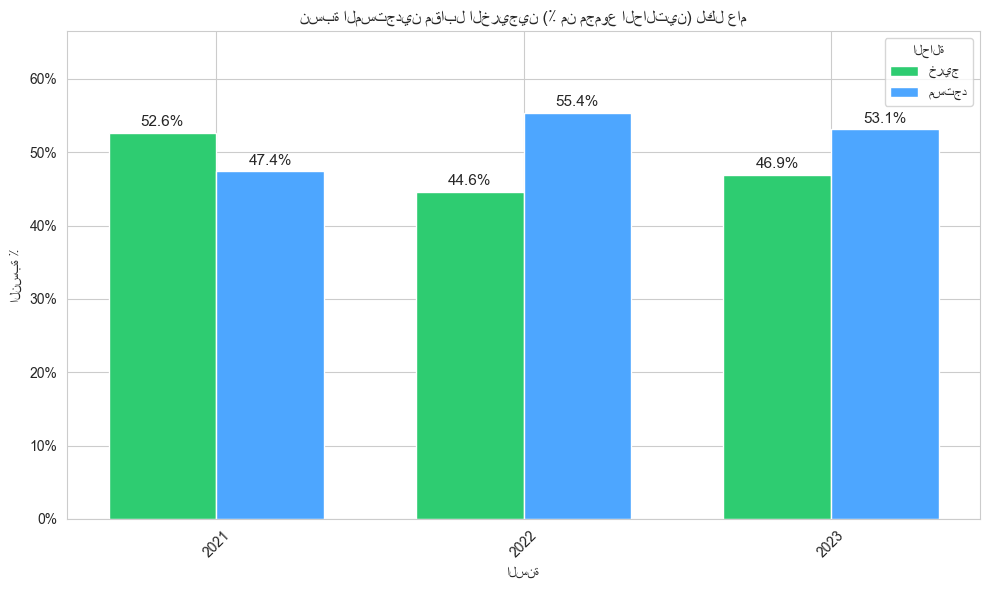

In [55]:
# نسبة المستجدين مقابل الخريجين لكل عام
df_status = df[
    (df["المرحلة الدراسية"] == "بكالوريوس") &
    (df["حالة_الطالب"].isin(["مستجد", "خريج"]))
].copy()

status_annual = df_status.groupby("السنة الدراسية")["العدد"].sum()

sts_long = df_status.groupby(["السنة الدراسية", "حالة_الطالب"])["العدد"].sum().reset_index()
sts_long["النسبة٪"] = sts_long.apply(
    lambda r: round(r["العدد"] / status_annual.get(r["السنة الدراسية"], 1) * 100, 1), axis=1
)
sts_long["السنة الدراسية"] = sts_long["السنة الدراسية"].astype(str)

color_map = {"مستجد": "#4DA6FF", "خريج": "#2ECC71"}
years = sts_long["السنة الدراسية"].unique()
statuses = sts_long["حالة_الطالب"].unique()
x = np.arange(len(years))
width = 0.35

plt.figure(figsize=(10, 6))

for i, status in enumerate(statuses):
    subset = sts_long[sts_long["حالة_الطالب"] == status]
    bars = plt.bar(
        x + i * width, subset["النسبة٪"],
        width=width, label=status,
        color=color_map.get(status, None)
    )
    for bar, val in zip(bars, subset["النسبة٪"]):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.1f}%",
            ha="center", va="bottom", fontsize=11
        )

plt.xticks(x + width / 2, years, rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
plt.ylim(0, sts_long["النسبة٪"].max() * 1.2)
plt.title("نسبة المستجدين مقابل الخريجين (٪ من مجموع الحالتين) لكل عام")
plt.ylabel("النسبة ٪")
plt.xlabel("السنة")
plt.legend(title="الحالة")
plt.tight_layout()
plt.show()